##Fase 1: Entendimiento del problema

## Dataset

Vamos a utilizar uno de los datasets disponible por la Universidad de California Irvine, en este caso: Diabetes de Pima Indians. Este dataset es un conjunto de datos disponible de manera gratuita desde el repositorio UCI Machine Learning. Describe los datos de registros médicos de los pacientes de de Pima y describe si ellos tuvieron diabetes dentro de un periodo de cinco años. Es un problema de clasificación binaria (aparición de diabetes como 1 o no como 0). Las variables de entrada que describen a cada paciente son numéricas y tienen escalas variables. A continuación se enumeran los ocho atributos para el conjunto de datos:

1. Número de veces embarazada.
2. Concentración de glucosa plasmática a 2 horas en una prueba oral de tolerancia a la glucosa.
3. Presión arterial diastólica (mm Hg).
4. Grosor del pliegue de la piel del tríceps (mm).
5. Insulina en suero de 2 horas (mu U / ml).
6. Índice de masa corporal.
7. Función de pedigrí de diabetes.
8. Edad (años).
9. Clase, aparición de diabetes dentro de los cinco años.

Debido a que todos los atributos son numericos, es facil utilizarlos directo en la red neuronal. Este dataset contiene 768 registros.

**El problema consiste en desarrollar un modelo de clasificación binaria capaz de predecir la aparición de diabetes en un período de cinco años, utilizando variables clínicas numéricas de pacientes Pima Indians. Debido a que se trata de un problema médico, es importante considerar el costo de los errores, especialmente los falsos negativos, ya que no detectar un paciente en riesgo puede tener consecuencias graves.**

### Cargar Datos


In [ ]:
# Instalar gdown
!pip install -q gdown

In [ ]:
# Descargar el archivo desde Google Drive
!gdown 1BYCy2frkkih7lpEbGRMSV6OC4xLKwqFm --output pima-indians-diabetes.csv

Downloading...
From: https://drive.google.com/uc?id=1BYCy2frkkih7lpEbGRMSV6OC4xLKwqFm
To: /content/pima-indians-diabetes.csv
100% 23.3k/23.3k [00:00<00:00, 14.5MB/s]


In [ ]:
import numpy as np

dataset = np.loadtxt("pima-indians-diabetes.csv", delimiter=",")
print("Original: ",dataset.shape)
print(dataset[:3])

Original:  (768, 9)
[[  6.    148.     72.     35.      0.     33.6     0.627  50.      1.   ]
 [  1.     85.     66.     29.      0.     26.6     0.351  31.      0.   ]
 [  8.    183.     64.      0.      0.     23.3     0.672  32.      1.   ]]


#Fase 2: EDA



*  Análisis descriptivo
* Detección de valores imposibles
* Análisis por clase
* Desbalance
* Correlaciones



In [ ]:
import pandas as pd

df = pd.DataFrame(dataset)
df.columns = ["Preg", "Gluc", "BP", "Skin", "Ins", "BMI", "DPF", "Age", "Target"]
df.head()

,Preg,Gluc,BP,Skin,Ins,BMI,DPF,Age,Target
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Preg    768 non-null    float64
 1   Gluc    768 non-null    float64
 2   BP      768 non-null    float64
 3   Skin    768 non-null    float64
 4   Ins     768 non-null    float64
 5   BMI     768 non-null    float64
 6   DPF     768 non-null    float64
 7   Age     768 non-null    float64
 8   Target  768 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Preg,Gluc,BP,Skin,Ins,BMI,DPF,Age,Target
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Análisis Descriptivo Detallado

### Subtask:
Realizar un análisis descriptivo detallado del DataFrame `df`, incluyendo estadísticas como la media, mediana, desviación estándar, rangos y cuantiles para todas las variables numéricas. Esto complementará la información ya obtenida con `df.describe()` y `df.info()`.


**Reasoning**:
The subtask requires displaying the median of all numerical variables in the DataFrame `df`. The `df.median()` method can be used for this purpose.



In [ ]:
print("Mediana de todas las variables:\n", df.median())

Mediana de todas las variables:
 Preg        3.0000
Gluc      117.0000
BP         72.0000
Skin       23.0000
Ins        30.5000
BMI        32.0000
DPF         0.3725
Age        29.0000
Target      0.0000
dtype: float64


## Detección de Valores Imposibles y Conteo

### Subtask:
Identificar y contar la cantidad de valores '0' en columnas donde lógicamente no deberían existir (como Glucosa, Presión Sanguínea, Grosor de la Piel, Insulina y BMI), ya que un valor de 0 en estas columnas podría indicar datos faltantes o incorrectos.


**Reasoning**:
The subtask requires identifying and counting zero values in specified columns. I will generate a code block that iterates through the given columns ('Gluc', 'BP', 'Skin', 'Ins', 'BMI') and prints the count of zero values for each.



In [ ]:
print("\nConteo de valores '0' en columnas clave:")
columns_with_potential_zeros = ["Gluc", "BP", "Skin", "Ins", "BMI"]
for col in columns_with_potential_zeros:
    zero_count = (df[col] == 0).sum()
    perecentage = (zero_count / len(df)) * 100
    print(f"La columna '{col}' tiene {zero_count}, ({perecentage}) valores '0'.")


Conteo de valores '0' en columnas clave:
La columna 'Gluc' tiene 5, (0.6510416666666667) valores '0'.
La columna 'BP' tiene 35, (4.557291666666666) valores '0'.
La columna 'Skin' tiene 227, (29.557291666666668) valores '0'.
La columna 'Ins' tiene 374, (48.69791666666667) valores '0'.
La columna 'BMI' tiene 11, (1.4322916666666665) valores '0'.


## Análisis de Desbalance de Clases

### Subtask:
Determinar y visualizar la distribución de la variable objetivo ('Target') para identificar si existe un desbalance significativo entre las clases (diabéticos y no diabéticos). Se generará un gráfico de barras para esta visualización.


**Reasoning**:
To determine and visualize the distribution of the 'Target' variable, I need to first calculate its value counts and proportions, then create a bar plot using Seaborn and Matplotlib for visualization. The specified imports for `matplotlib.pyplot` and `seaborn` are necessary for this visualization task.




Distribución de la variable objetivo 'Target':
Target
0.0    500
1.0    268
Name: count, dtype: int64

Proporción de la variable objetivo 'Target':
Target
0.0    0.651042
1.0    0.348958
Name: proportion, dtype: float64


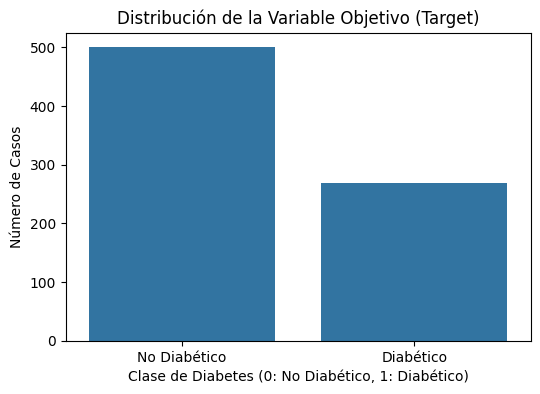

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nDistribución de la variable objetivo 'Target':")
print(df['Target'].value_counts())
print("\nProporción de la variable objetivo 'Target':")
print(df['Target'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df)
plt.title('Distribución de la Variable Objetivo (Target)')
plt.xlabel('Clase de Diabetes (0: No Diabético, 1: Diabético)')
plt.ylabel('Número de Casos')
plt.xticks([0, 1], ['No Diabético', 'Diabético'])
plt.show()

**Reasoning**:
The next step in the EDA is to visualize the distributions of all predictor variables using histograms or KDE plots, as outlined in the main task. This helps understand the shape and spread of each feature.




Visualización de las distribuciones de las variables predictoras:


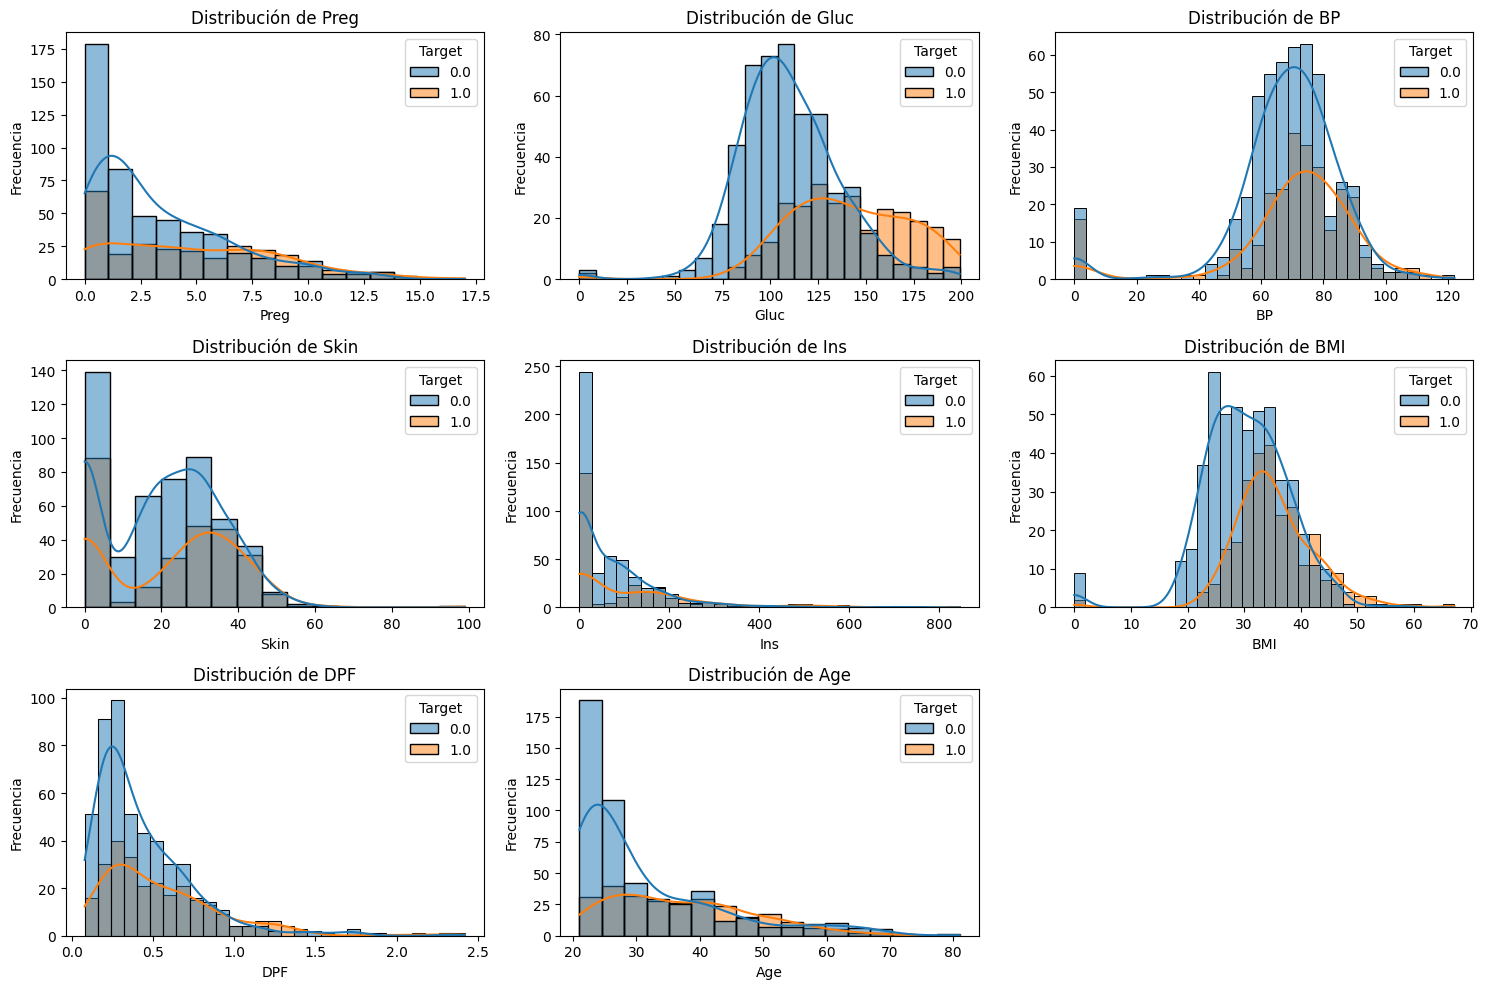

In [ ]:
print("\nVisualización de las distribuciones de las variables predictoras:")
features = df.columns.drop('Target')
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=df, x=col, kde=True, hue="Target" ) # Corregido: pasar el DataFrame completo 'df' a 'data' y el nombre de la columna a 'x'
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Reasoning**:
Following the EDA plan, the next step is to generate boxplots for each predictor variable, grouped by the 'Target' variable, to visualize how the distributions of features differ between the two classes (diabetic vs. non-diabetic).




Boxplots de variables predictoras por clase de Target (excluyendo ceros imposibles):


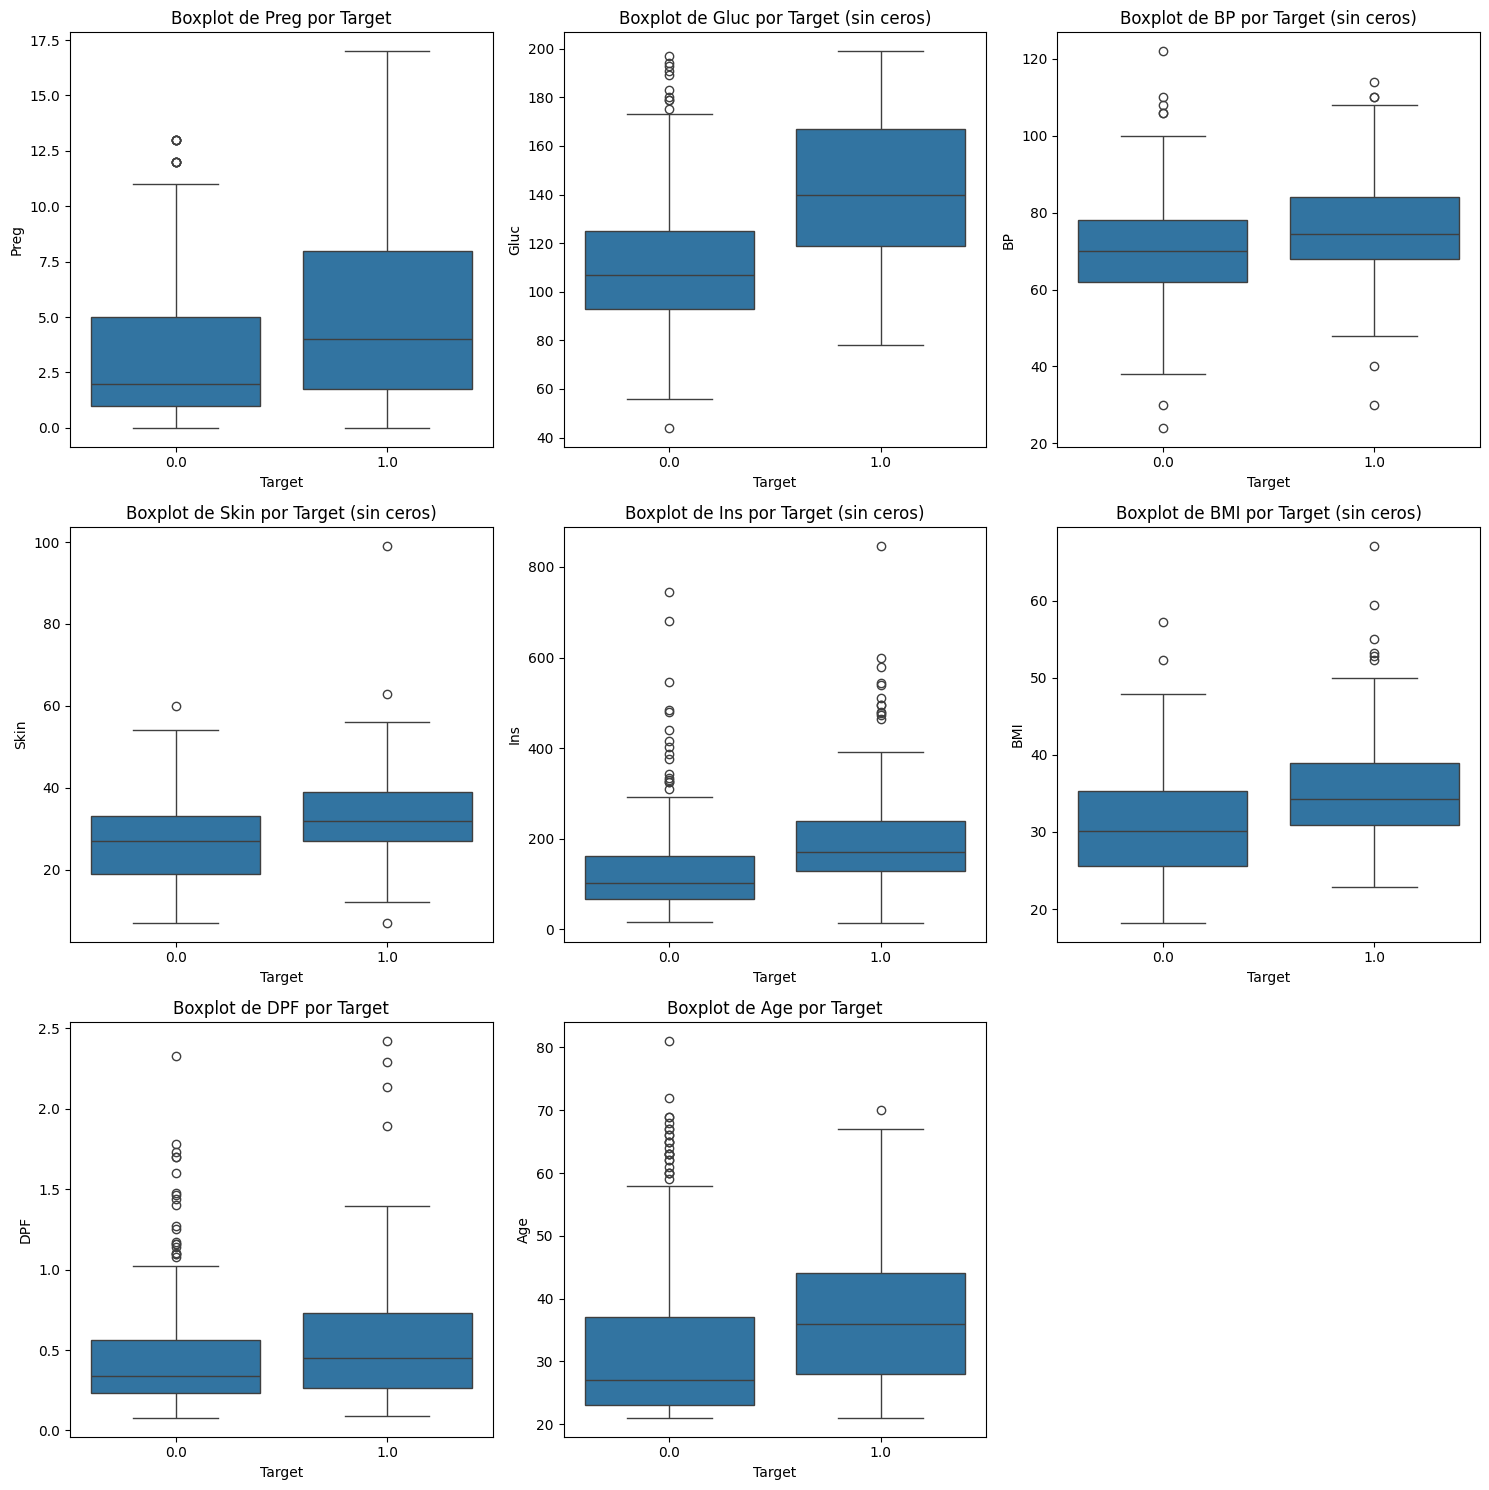

In [ ]:
print("\nBoxplots de variables predictoras por clase de Target (excluyendo ceros imposibles):")
plt.figure(figsize=(15, 15))
columns_to_filter_zeros = ["Gluc", "BP", "Skin", "Ins", "BMI"]

for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)

    if col in columns_to_filter_zeros:
        # Filter out rows where the current column has a value of 0
        df_filtered_for_plot = df[df[col] != 0]
        sns.boxplot(x='Target', y=col, data=df_filtered_for_plot)
    else:
        # For other columns, use the original DataFrame
        sns.boxplot(x='Target', y=col, data=df)

    plt.title(f'Boxplot de {col} por Target (sin ceros)' if col in columns_to_filter_zeros else f'Boxplot de {col} por Target')
    plt.xlabel('Target')
    plt.ylabel(col)
plt.tight_layout()
plt.show()


Matriz de correlación entre todas las variables:


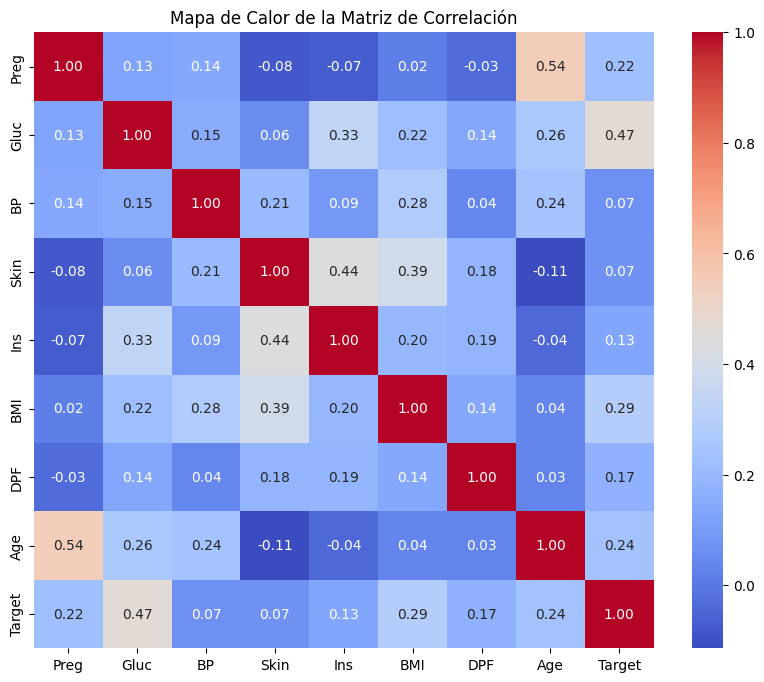

In [ ]:
print("\nMatriz de correlación entre todas las variables:")
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

#Fase 3: División de datos




In [ ]:
from sklearn.model_selection import train_test_split

# Separar las características (X) de la variable objetivo (y)
X = df.drop('Target', axis=1)
y = df['Target']

# Dividir los datos en conjuntos de entrenamiento y prueba (80% train, 20% test)
# random_state asegura que la división sea reproducible
# stratify=y asegura que la proporción de las clases de 'Target' sea la misma en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones de los datos de entrenamiento:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nDimensiones de los datos de prueba:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print("\nProporción de la clase 'Target' en y_train:")
print(y_train.value_counts(normalize=True))

print("\nProporción de la clase 'Target' en y_test:")
print(y_test.value_counts(normalize=True))

Dimensiones de los datos de entrenamiento:
X_train: (614, 8)
y_train: (614,)

Dimensiones de los datos de prueba:
X_test: (154, 8)
y_test: (154,)

Proporción de la clase 'Target' en y_train:
Target
0.0    0.651466
1.0    0.348534
Name: proportion, dtype: float64

Proporción de la clase 'Target' en y_test:
Target
0.0    0.649351
1.0    0.350649
Name: proportion, dtype: float64


#Fase 4: Preprocesamiento (solo con train)

# Task
```tool_code
import numpy as np

# Crear copias de los DataFrames para no modificar los originales
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

# Columnas donde los ceros deben ser tratados como valores nulos
columns_to_impute = ['Gluc', 'BP', 'Skin', 'Ins', 'BMI']

# Reemplazar los valores '0' por np.nan en las columnas especificadas para X_train_imputed
for col in columns_to_impute:
    X_train_imputed[col] = X_train_imputed[col].replace(0, np.nan)
    X_test_imputed[col] = X_test_imputed[col].replace(0, np.nan)

print("Número de valores NaN después de reemplazar los ceros en X_train_imputed:")
print(X_train_imputed[columns_to_impute].isnull().sum())

print("\nNúmero de valores NaN después de reemplazar los ceros en X_test_imputed:")
print(X_test_imputed[columns_to_impute].isnull().sum())
```

## Preprocesamiento: Reemplazar Ceros por NaN

### Subtask:
Convertir los valores '0' en las columnas 'Gluc', 'BP', 'Skin', 'Ins', 'BMI' a 'np.nan' en las copias de los DataFrames de entrenamiento y prueba (`X_train_imputed` y `X_test_imputed`).


In [ ]:
import numpy as np

# Crear copias de los DataFrames de entrenamiento y prueba para imputación
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

# Definir las columnas donde los ceros se considerarán valores faltantes
columns_to_replace_zeros = ['Gluc', 'BP', 'Skin', 'Ins', 'BMI']

# Reemplazar los valores '0' por 'np.nan' en las columnas especificadas para X_train_imputed
for col in columns_to_replace_zeros:
    X_train_imputed[col] = X_train_imputed[col].replace(0, np.nan)

# Reemplazar los valores '0' por 'np.nan' en las columnas especificadas para X_test_imputed
for col in columns_to_replace_zeros:
    X_test_imputed[col] = X_test_imputed[col].replace(0, np.nan)

print("Número de valores NaN resultantes en X_train_imputed por columna:")
for col in columns_to_replace_zeros:
    nan_count = X_train_imputed[col].isnull().sum()
    percentage = (nan_count / len(X_train_imputed)) * 100
    print(f"  '{col}': {nan_count} ({percentage:.2f}%) NaN values")

print("\nNúmero de valores NaN resultantes en X_test_imputed por columna:")
for col in columns_to_replace_zeros:
    nan_count = X_test_imputed[col].isnull().sum()
    percentage = (nan_count / len(X_test_imputed)) * 100
    print(f"  '{col}': {nan_count} ({percentage:.2f}%) NaN values")

Número de valores NaN resultantes en X_train_imputed por columna:
  'Gluc': 4 (0.65%) NaN values
  'BP': 23 (3.75%) NaN values
  'Skin': 175 (28.50%) NaN values
  'Ins': 290 (47.23%) NaN values
  'BMI': 9 (1.47%) NaN values

Número de valores NaN resultantes en X_test_imputed por columna:
  'Gluc': 1 (0.65%) NaN values
  'BP': 12 (7.79%) NaN values
  'Skin': 52 (33.77%) NaN values
  'Ins': 84 (54.55%) NaN values
  'BMI': 2 (1.30%) NaN values


## Imputación por Mediana

### Subtask:
Utilizar `sklearn.impute.SimpleImputer` con `strategy='median'` para imputar las columnas 'Gluc', 'BP', 'BMI' en `X_train_imputed` y `X_test_imputed`, asegurando que el imputador se entrene solo con los datos de entrenamiento.


In [ ]:
from sklearn.impute import SimpleImputer

# Columnas a imputar con la mediana
columns_for_median_imputation = ['Gluc', 'BP', 'BMI']

# Crear una instancia del imputador con estrategia de mediana
median_imputer = SimpleImputer(strategy='median')

# Entrenar el imputador exclusivamente con los datos de entrenamiento para las columnas seleccionadas
median_imputer.fit(X_train_imputed[columns_for_median_imputation])

# Aplicar la transformación a los conjuntos de entrenamiento y prueba
X_train_imputed[columns_for_median_imputation] = median_imputer.transform(X_train_imputed[columns_for_median_imputation])
X_test_imputed[columns_for_median_imputation] = median_imputer.transform(X_test_imputed[columns_for_median_imputation])

print("Valores NaN después de la imputación por mediana en X_train_imputed para Gluc, BP, BMI:")
print(X_train_imputed[columns_for_median_imputation].isnull().sum())

print(
"\nValores NaN después de la imputación por mediana en X_test_imputed para Gluc, BP, BMI:")
print(X_test_imputed[columns_for_median_imputation].isnull().sum())

Valores NaN después de la imputación por mediana en X_train_imputed para Gluc, BP, BMI:
Gluc    0
BP      0
BMI     0
dtype: int64

Valores NaN después de la imputación por mediana en X_test_imputed para Gluc, BP, BMI:
Gluc    0
BP      0
BMI     0
dtype: int64


## Imputación Iterativa (Alternativa a MissForest)

### Subtask:
Utilizar `sklearn.impute.IterativeImputer` con `RandomForestRegressor` como estimador para imputar las columnas restantes con valores NaN ('Skin' e 'Ins') en `X_train_imputed` y `X_test_imputed`, asegurando que el imputador se entrene solo con los datos de entrenamiento.


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Columnas a imputar con el imputador iterativo (incluyendo todas las que tienen NaN)
# Aunque el enfoque es para 'Skin' e 'Ins', el imputador iterativo usa todas las columnas para la imputación

# 2. Crear una instancia de RandomForestRegressor como estimador
rf_estimator = RandomForestRegressor(random_state=42, n_estimators=200, min_samples_leaf=3)

# 3. Crear una instancia de IterativeImputer
iterative_imputer = IterativeImputer(estimator=rf_estimator, random_state=42, max_iter=10)

# 4. Entrenar el IterativeImputer con los datos de entrenamiento (X_train_imputed)
# El fit se hace sobre el DataFrame completo para aprovechar las correlaciones entre todas las características
iterative_imputer.fit(X_train_imputed)

# 5. Transformar X_train_imputed y X_test_imputed
X_train_imputed_array = iterative_imputer.transform(X_train_imputed)
X_test_imputed_array = iterative_imputer.transform(X_test_imputed)

# Convertir los arrays de vuelta a DataFrames para mantener los nombres de las columnas
X_train_imputed = pd.DataFrame(X_train_imputed_array, columns=X_train_imputed.columns, index=X_train_imputed.index)
X_test_imputed = pd.DataFrame(X_test_imputed_array, columns=X_test_imputed.columns, index=X_test_imputed.index)

# 6. Verificar que las columnas 'Skin' e 'Ins' ya no contengan valores NaN
print("\nValores NaN después de la imputación iterativa en X_train_imputed:")
print(X_train_imputed[['Skin', 'Ins']].isnull().sum())

print("\nValores NaN después de la imputación iterativa en X_test_imputed:")
print(X_test_imputed[['Skin', 'Ins']].isnull().sum())

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



Valores NaN después de la imputación iterativa en X_train_imputed:
Skin    0
Ins     0
dtype: int64

Valores NaN después de la imputación iterativa en X_test_imputed:
Skin    0
Ins     0
dtype: int64


## Verificar Imputación



In [ ]:
columns_to_check = ['Gluc', 'BP', 'Skin', 'Ins', 'BMI']

print("Verificación de valores NaN en X_train_imputed después de la imputación:")
print(X_train_imputed[columns_to_check].isnull().sum())

print(
"\nVerificación de valores NaN en X_test_imputed después de la imputación:")
print(X_test_imputed[columns_to_check].isnull().sum())

Verificación de valores NaN en X_train_imputed después de la imputación:
Gluc    0
BP      0
Skin    0
Ins     0
BMI     0
dtype: int64

Verificación de valores NaN en X_test_imputed después de la imputación:
Gluc    0
BP      0
Skin    0
Ins     0
BMI     0
dtype: int64


In [ ]:
X_train_imputed.describe()

,Preg,Gluc,BP,Skin,Ins,BMI,DPF,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.819218,121.671010,72.140065,28.963999,147.667099,32.448208,0.477428,33.366450
std,3.314148,30.003794,12.275119,9.665918,90.895986,6.824122,0.330300,11.833438
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.084000,21.000000
25%,1.000000,99.000000,64.000000,22.000000,87.000344,27.625000,0.245000,24.000000
50%,3.000000,117.000000,72.000000,28.976189,129.658592,32.400000,0.382500,29.000000
75%,6.000000,140.000000,80.000000,35.614656,185.000000,36.500000,0.639250,41.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000


In [ ]:
from sklearn.ensemble import IsolationForest

# Crear una instancia del modelo Isolation Forest
# El parámetro 'contamination' es la proporción esperada de outliers en el dataset.
# Lo establecemos en 'auto' para que el algoritmo lo infiera, o se puede establecer un valor fijo (ej. 0.05).
# random_state para reproducibilidad.
isolation_forest_model = IsolationForest(random_state=42, contamination=0.1)

# Entrenar el modelo con los datos escalados de entrenamiento
isolation_forest_model.fit(X_train_imputed)

# Predecir los outliers. -1 indica outlier, 1 indica inlier.
outliers_predictions = isolation_forest_model.predict(X_train_imputed)

# Contar el número de outliers detectados (-1)
num_outliers = list(outliers_predictions).count(-1)

print(f"Número de outliers detectados en X_train_imputed: {num_outliers}")
print(f"Porcentaje de outliers detectados: {(num_outliers / len(X_train_imputed)) * 100:.2f}%")


Número de outliers detectados en X_train_imputed: 62
Porcentaje de outliers detectados: 10.10%


In [ ]:
import numpy as np

# Identificar los índices de los inliers (no-outliers)
inlier_indices = outliers_predictions == 1

# Crear una copia del DataFrame escalado para aplicar winsorization
X_train_winsorized = X_train_imputed.copy()

print("Aplicando winsorization a X_train_imputed...")

# Aplicar winsorization por columna
for col in X_train_winsorized.columns:
    # Calcular los percentiles 5 y 95 usando solo los datos *inliers* de esa columna
    # Esto ayuda a que los límites de winsorization no sean sesgados por los propios outliers
    lower_bound = X_train_imputed.loc[inlier_indices, col].quantile(0.05)
    upper_bound = X_train_imputed.loc[inlier_indices, col].quantile(0.95)

    # Aplicar el winsorization: los valores fuera de los límites se ajustan a los límites
    X_train_winsorized[col] = np.clip(X_train_winsorized[col], lower_bound, upper_bound)

print("Winsorization aplicada. Comparando estadísticas descriptivas:")





Aplicando winsorization a X_train_scaled...
Winsorization aplicada. Comparando estadísticas descriptivas:


In [ ]:
X_train_final = X_train_winsorized.copy()
X_test_final = X_test_imputed.copy()

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Crear una instancia de StandardScaler
scaler = StandardScaler()

# Entrenar el escalador exclusivamente con los datos de entrenamiento
scaler.fit(X_train_final)

# Transformar los conjuntos de entrenamiento y prueba
X_train_scaled_array = scaler.transform(X_train_final)
X_test_scaled_array = scaler.transform(X_test_final)

# Convertir los arrays resultantes de la transformación de nuevo a DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train_final.columns, index=X_train_final.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test_final.columns, index=X_test_final.index)

print("Verificación de las estadísticas de X_train_scaled (media ~0, std ~1):")
print(X_train_scaled.describe().loc[['mean', 'std']])

Verificación de las estadísticas de X_train_scaled (media ~0, std ~1):
              Preg          Gluc            BP          Skin           Ins  \
mean  5.786179e-18  1.909439e-16  6.205677e-16 -4.628943e-16  8.679268e-18   
std   1.000815e+00  1.000815e+00  1.000815e+00  1.000815e+00  1.000815e+00   

               BMI           DPF           Age  
mean  1.118179e-15  1.996232e-16  8.679268e-17  
std   1.000815e+00  1.000815e+00  1.000815e+00  


In [ ]:
X_train_final = X_train_scaled.copy()
X_test_final = X_test_scaled.copy()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Crear una instancia del modelo KNN
# Se usa n_neighbors=5 como valor por defecto, un buen punto de partida.
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Entrenar el modelo con los datos de entrenamiento procesados
knn_model.fit(X_train_final, y_train)

# 3. Realizar predicciones en el conjunto de entrenamiento
y_train_pred = knn_model.predict(X_train_final)

# 4. Realizar predicciones en el conjunto de prueba
y_test_pred = knn_model.predict(X_test_final)

# 5. Evaluar el rendimiento del modelo
print("\n--- Evaluación del modelo KNN --- ")

print("\nRendimiento en el conjunto de ENTRENAMIENTO:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(classification_report(y_train, y_train_pred))

print("\nRendimiento en el conjunto de PRUEBA:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(classification_report(y_test, y_test_pred))


--- Evaluación del modelo KNN --- 

Rendimiento en el conjunto de ENTRENAMIENTO:
Accuracy: 0.8094
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86       400
         1.0       0.75      0.68      0.71       214

    accuracy                           0.81       614
   macro avg       0.79      0.78      0.79       614
weighted avg       0.81      0.81      0.81       614


Rendimiento en el conjunto de PRUEBA:
Accuracy: 0.7338
              precision    recall  f1-score   support

         0.0       0.78      0.82      0.80       100
         1.0       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



#Fase 6: Red neuronal

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.initializers import HeNormal

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

MLP = Sequential()
MLP.add(Dense(32, activation='relu', kernel_initializer=HeNormal(), input_dim=8))
MLP.add(BatchNormalization())
MLP.add(Dropout(0.1))
MLP.add(Dense(16, activation='relu', kernel_initializer=HeNormal()))
MLP.add(BatchNormalization())
MLP.add(Dropout(0.1))
MLP.add(Dense(8, activation='relu', kernel_initializer=HeNormal()))
MLP.add(Dense(1, activation='sigmoid')) # Esta línea estaba comentada y es necesaria para la clasificación binaria

MLP.compile(optimizer='adam', loss='binary_crossentropy', metrics=['recall', 'accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0,1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {0: weights[0], 1: weights[1]}
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42, stratify=y_train
)

hist = MLP.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early],
    class_weight=class_weight,
    verbose=1
)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.5808 - loss: 0.8638 - recall: 0.0652 - val_accuracy: 0.5203 - val_loss: 0.6929 - val_recall: 0.0233
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6218 - loss: 0.7637 - recall: 0.0472 - val_accuracy: 0.5122 - val_loss: 0.6682 - val_recall: 0.0465
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5946 - loss: 0.7578 - recall: 0.0507 - val_accuracy: 0.5610 - val_loss: 0.6574 - val_recall: 0.1395
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5914 - loss: 0.7554 - recall: 0.1188 - val_accuracy: 0.6260 - val_loss: 0.6423 - val_recall: 0.3721
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6595 - loss: 0.6631 - recall: 0.2624 - val_accuracy: 0.6829 - val_loss: 0.6228 - val_recall: 0.5116
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6676 - loss: 0.6566 - recall: 0.3465 - val_accuracy: 0.7317 - val_loss: 0.6010 - val_recall: 0.6512
Epoc

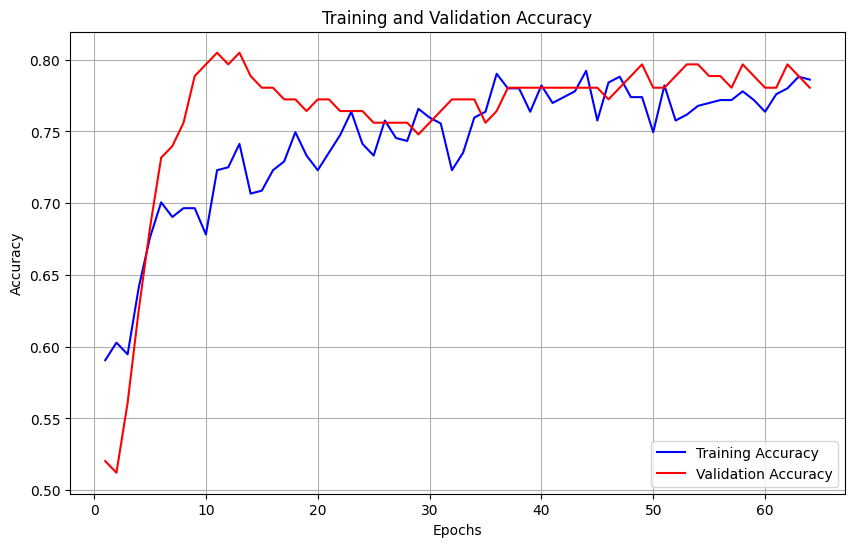

Último Training Accuracy: 0.7862
Último Validation Accuracy: 0.7805


In [ ]:
import matplotlib.pyplot as plt

# Obtener los valores de accuracy y val_accuracy del historial de entrenamiento
training_accuracy = hist.history['accuracy']
validation_accuracy = hist.history['val_accuracy']
epochs = range(1, len(training_accuracy) + 1)

# Graficar la accuracy de entrenamiento y validación
plt.figure(figsize=(10, 6))
plt.plot(epochs, training_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Último Training Accuracy: {training_accuracy[-1]:.4f}")
print(f"Último Validation Accuracy: {validation_accuracy[-1]:.4f}")

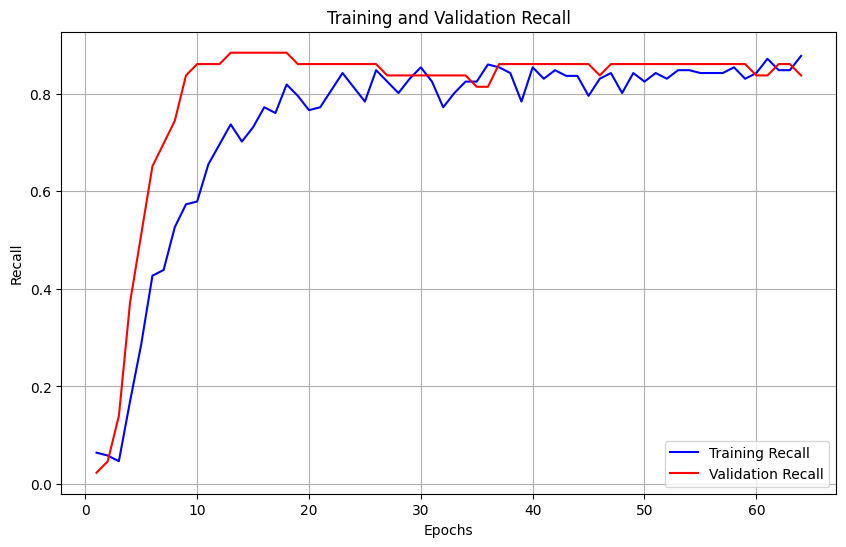

Último Training Recall: 0.8772
Último Validation Recall: 0.8372


In [ ]:
import matplotlib.pyplot as plt

# Obtener los valores de recall y val_recall del historial de entrenamiento
training_recall = hist.history['recall']
validation_recall = hist.history['val_recall']
epochs = range(1, len(training_recall) + 1)

# Graficar el recall de entrenamiento y validación
plt.figure(figsize=(10, 6))
plt.plot(epochs, training_recall, 'b', label='Training Recall')
plt.plot(epochs, validation_recall, 'r', label='Validation Recall')
plt.title('Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()

print(f"Último Training Recall: {training_recall[-1]:.4f}")
print(f"Último Validation Recall: {validation_recall[-1]:.4f}")

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, recall_score

# 1. Realizar predicciones en el conjunto de prueba (probabilidades)
y_pred_proba = MLP.predict(X_test_final)

# 2. Convertir las probabilidades a clases binarias (0 o 1)
# Se utiliza un umbral de 0.5 para la clasificación binaria
y_pred = np.round(y_pred_proba)

# 3. Evaluar el rendimiento del modelo en el conjunto de prueba
print("\n--- Evaluación del modelo MLP en el conjunto de PRUEBA ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

--- Evaluación del modelo MLP en el conjunto de PRUEBA ---
Accuracy: 0.7403
Recall: 0.7407
              precision    recall  f1-score   support

         0.0       0.84      0.74      0.79       100
         1.0       0.61      0.74      0.67        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.76      0.74      0.74       154



In [ ]:
# Guardar el modelo en formato HDF5
MLP.save('mlp_diabetes_model.h5')
print("Modelo MLP guardado exitosamente como 'mlp_diabetes_model.h5'")

Modelo MLP guardado exitosamente como 'mlp_diabetes_model.h5'


# Cross validation

The task is to perform a stratified 5-fold cross-validation for a Multi-Layer Perceptron (MLP) model to predict diabetes. For each fold, the data will be preprocessed by replacing zeros with NaNs, imputing NaNs using median and iterative (RandomForestRegressor) methods, performing winsorization for outlier handling, and scaling features with `StandardScaler`. The MLP model will be re-initialized and trained with class weights on each fold, and the average accuracy and recall, along with their standard deviations across all folds, will be calculated and reported. Finally, the cross-validation results will be summarized to assess the model's performance and stability.

## Define MLP Model Function

### Subtask:
Define una función que cree y compile el modelo MLP con la arquitectura, inicializadores, normalización por lotes, abandono y función de activación Sigmoid para la capa de salida, listo para la clasificación binaria. Esta función será llamada para inicializar un nuevo modelo en cada pliegue de la validación cruzada.


**Reasoning**:
The subtask requires defining a Python function that builds and compiles a Keras Sequential MLP model with a specified architecture and parameters for binary classification. This function will be defined in a code block.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal

def create_mlp_model():
    MLP = Sequential()
    MLP.add(Dense(32, activation='relu', kernel_initializer=HeNormal(), input_dim=8))
    MLP.add(BatchNormalization())
    MLP.add(Dropout(0.1))
    MLP.add(Dense(16, activation='relu', kernel_initializer=HeNormal()))
    MLP.add(BatchNormalization())
    MLP.add(Dropout(0.1))
    MLP.add(Dense(8, activation='relu', kernel_initializer=HeNormal()))
    MLP.add(Dense(1, activation='sigmoid'))

    MLP.compile(optimizer='adam', loss='binary_crossentropy', metrics=['recall', 'accuracy'])
    return MLP

print("Función 'create_mlp_model' definida exitosamente.")

Función 'create_mlp_model' definida exitosamente.


## Setup Cross-Validation and Metrics Storage

### Subtask:
Initialize `StratifiedKFold` for the cross-validation, dividing the training data into 5 folds, ensuring that the proportion of the target classes is maintained in each split. Also, initialize empty lists to store the accuracy and recall metrics from each fold.


**Reasoning**:
To set up the cross-validation, I need to import `StratifiedKFold`, initialize it with the specified parameters, and create empty lists to store accuracy and recall scores for each fold.



In [ ]:
from sklearn.model_selection import StratifiedKFold

# Initialize StratifiedKFold for 5 splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
recall_scores = []

print("StratifiedKFold initialized and metric lists created.")

StratifiedKFold initialized and metric lists created.


## Cross-Validation Loop

This section implements the stratified 5-fold cross-validation for the MLP model. For each fold, the following steps will be executed to ensure robust evaluation and prevent data leakage:

1.  **Splitting Data**: The `StratifiedKFold` object (`skf`) will split the `X` (features) and `y` (target) data into training and validation sets, maintaining the original class distribution in each split.

2.  **Preprocessing Pipeline (per fold)**:
    *   **Zero-to-NaN Conversion**: For each fold's training and validation sets, '0' values in 'Gluc', 'BP', 'Skin', 'Ins', and 'BMI' will be replaced with `np.nan`.
    *   **Median Imputation**: `SimpleImputer` (strategy='median') will be fitted on the *training data* for 'Gluc', 'BP', and 'BMI' and then used to transform both the training and validation sets.
    *   **Iterative Imputation**: `IterativeImputer` with `RandomForestRegressor` will be fitted on the *training data* (after median imputation) to impute 'Skin' and 'Ins', and then used to transform both training and validation sets.
    *   **Outlier Handling (Winsorization)**: Isolation Forest will be trained on the imputed training data to identify outliers. Then, winsorization (clipping values at the 5th and 95th percentiles of *inlier* data) will be applied to the training data. The same clipping values (derived from the training inliers) will be applied to the validation data. This helps mitigate the impact of extreme values.
    *   **Feature Scaling**: `StandardScaler` will be fitted on the *final preprocessed training data* and then used to scale both the preprocessed training and validation sets.

3.  **Class Weight Calculation**: Class weights will be computed based on the training set of the current fold to address the class imbalance, ensuring the model gives appropriate importance to the minority class.

4.  **Model Re-initialization and Training**: A fresh MLP model will be created using `create_mlp_model()` for each fold. It will then be trained on the preprocessed training data, using the calculated class weights and `EarlyStopping` based on validation loss.

5.  **Evaluation**: After training, the model's performance (accuracy and recall) will be evaluated on the preprocessed validation set of the current fold, and the scores will be stored.

**Reasoning**:
Now, I will implement the cross-validation loop, performing all the preprocessing steps and model training for each fold, as detailed in the previous markdown block.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Prepare the full dataset for splitting within the loop
X_full = df.drop('Target', axis=1)
y_full = df['Target']

# Lists to store metrics for each fold
accuracy_scores = []
recall_scores = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(skf.split(X_full, y_full)):
    print(f"\n--- Fold {fold+1}/5 ---")

    # Split data for the current fold
    X_train_fold, X_val_fold = X_full.iloc[train_index], X_full.iloc[val_index]
    y_train_fold, y_val_fold = y_full.iloc[train_index], y_full.iloc[val_index]

    # --- Preprocessing Pipeline for the current fold ---

    # 1. Zero-to-NaN Conversion
    X_train_imputed_fold = X_train_fold.copy()
    X_val_imputed_fold = X_val_fold.copy()
    columns_to_replace_zeros = ['Gluc', 'BP', 'Skin', 'Ins', 'BMI']

    for col in columns_to_replace_zeros:
        X_train_imputed_fold[col] = X_train_imputed_fold[col].replace(0, np.nan)
        X_val_imputed_fold[col] = X_val_imputed_fold[col].replace(0, np.nan)

    # 2. Median Imputation
    columns_for_median_imputation = ['Gluc', 'BP', 'BMI']
    median_imputer = SimpleImputer(strategy='median')
    median_imputer.fit(X_train_imputed_fold[columns_for_median_imputation])

    X_train_imputed_fold[columns_for_median_imputation] = median_imputer.transform(X_train_imputed_fold[columns_for_median_imputation])
    X_val_imputed_fold[columns_for_median_imputation] = median_imputer.transform(X_val_imputed_fold[columns_for_median_imputation])

    # 3. Iterative Imputation (for Skin, Ins, and potentially other remaining NaNs)
    rf_estimator = RandomForestRegressor(random_state=42, n_estimators=200, min_samples_leaf=3)
    iterative_imputer = IterativeImputer(estimator=rf_estimator, random_state=42, max_iter=10)

    # Fit on training data after median imputation, transform both train and val
    iterative_imputer.fit(X_train_imputed_fold)
    X_train_imputed_fold = pd.DataFrame(iterative_imputer.transform(X_train_imputed_fold), columns=X_train_imputed_fold.columns, index=X_train_imputed_fold.index)
    X_val_imputed_fold = pd.DataFrame(iterative_imputer.transform(X_val_imputed_fold), columns=X_val_imputed_fold.columns, index=X_val_imputed_fold.index)

    # 4. Outlier Handling (Winsorization using IsolationForest)
    isolation_forest_model = IsolationForest(random_state=42, contamination=0.1)
    isolation_forest_model.fit(X_train_imputed_fold)
    outliers_predictions = isolation_forest_model.predict(X_train_imputed_fold)
    inlier_indices = outliers_predictions == 1

    X_train_winsorized_fold = X_train_imputed_fold.copy()
    X_val_winsorized_fold = X_val_imputed_fold.copy()

    for col in X_train_winsorized_fold.columns:
        lower_bound = X_train_imputed_fold.loc[inlier_indices, col].quantile(0.05)
        upper_bound = X_train_imputed_fold.loc[inlier_indices, col].quantile(0.95)

        X_train_winsorized_fold[col] = np.clip(X_train_winsorized_fold[col], lower_bound, upper_bound)
        X_val_winsorized_fold[col] = np.clip(X_val_winsorized_fold[col], lower_bound, upper_bound)

    # 5. Feature Scaling
    scaler = StandardScaler()
    scaler.fit(X_train_winsorized_fold)

    X_train_scaled_fold = pd.DataFrame(scaler.transform(X_train_winsorized_fold), columns=X_train_winsorized_fold.columns, index=X_train_winsorized_fold.index)
    X_val_scaled_fold = pd.DataFrame(scaler.transform(X_val_winsorized_fold), columns=X_val_winsorized_fold.columns, index=X_val_winsorized_fold.index)

    # --- Model Training and Evaluation ---

    # Calculate class weights for the current fold's training data
    classes = np.array([0, 1])
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_fold)
    class_weight = {0: weights[0], 1: weights[1]}

    # Re-initialize MLP model for each fold
    mlp_model = create_mlp_model()

    # Early stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train the model
    history = mlp_model.fit(
        X_train_scaled_fold,
        y_train_fold,
        validation_data=(X_val_scaled_fold, y_val_fold),
        epochs=200,
        batch_size=32,
        callbacks=[early_stopping],
        class_weight=class_weight,
        verbose=0 # Set to 1 to see training progress per epoch
    )

    # Make predictions on the validation set
    y_pred_proba_fold = mlp_model.predict(X_val_scaled_fold)
    y_pred_fold = np.round(y_pred_proba_fold)

    # Evaluate metrics
    fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
    fold_recall = recall_score(y_val_fold, y_pred_fold)

    accuracy_scores.append(fold_accuracy)
    recall_scores.append(fold_recall)

    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")
    print(f"Fold {fold+1} Recall: {fold_recall:.4f}")

print("\n--- Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")



--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Fold 1 Accuracy: 0.7143
Fold 1 Recall: 0.6296

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Fold 2 Accuracy: 0.7338
Fold 2 Recall: 0.6852

--- Fold 3/5 ---


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Fold 3 Accuracy: 0.7532
Fold 3 Recall: 0.7037

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Fold 4 Accuracy: 0.7451
Fold 4 Recall: 0.7170

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Fold 5 Accuracy: 0.6993
Fold 5 Recall: 0.7736

--- Cross-Validation Results ---
Average Accuracy: 0.7291 (+/- 0.0198)
Average Recall: 0.7018 (+/- 0.0466)
